In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

from pathlib import Path
from MITRotor import IEA10MW

In [2]:
rotor = IEA10MW()

nElements = 26
nSections = 158

In [3]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [4]:
case_1_bem = []
# wrfles_wind = []
case_1_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/s000_v000/U07_lite.npz')))

In [5]:
case_4_bem = []
# wrfles_wind = []
case_4_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/s000_v000/U07_lite.npz')))

In [18]:
case_1_file_list = glob.glob("/home1/09909/smata/dir_scratch/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/base/case_1/input_sounding")
case_4_file_list = glob.glob("/home1/09909/smata/dir_scratch/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/base/case_4/input_sounding")

case_1_data = extract_columns(case_1_file_list)
case_4_data = extract_columns(case_4_file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * case_1_bem[0]['diameter']/2 + 378

In [8]:
case_1_bem[0]['rOverR'] == case_4_bem[0]['rOverR'] 

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [9]:
case_1_bem[0]['uinf'] == case_4_bem[0]['uinf'] 

np.True_

In [11]:
case_1_bem[0]['diameter'] == case_4_bem[0]['diameter'] 

np.True_

In [12]:
case_1_bem[0]['radius'] == case_4_bem[0]['radius'] 

np.True_

In [13]:
case_1_bem[0]['hub_diameter'] == case_4_bem[0]['hub_diameter'] 

np.True_

In [15]:
case_1_bem[0]['hub_radius'] == case_4_bem[0]['hub_radius'] 

np.True_

In [16]:
case_1_bem[0]['omega'] == case_4_bem[0]['omega'] 

array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [17]:
case_1_bem[0]['shapiroM'] == case_4_bem[0]['shapiroM'] 

array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [24]:
case = 'case_1'

In [25]:
case_1_u_func = interp1d(case_1_data[case][:,0], case_1_data[case][:,1], kind='linear')
case_1_v_func = interp1d(case_1_data[case][:,0], case_1_data[case][:,2], kind='linear')

case_1_u_inf = case_1_u_func(Y)
case_1_v_inf = case_1_v_func(Y)

In [26]:
case = 'case_4'

In [27]:
case_4_u_func = interp1d(case_4_data[case][:,0], case_4_data[case][:,1], kind='linear')
case_4_v_func = interp1d(case_4_data[case][:,0], case_4_data[case][:,2], kind='linear')

case_4_u_inf = case_4_u_func(Y)
case_4_v_inf = case_4_v_func(Y)

In [31]:
np.sum((case_1_u_inf == case_4_u_inf) == False)

np.int64(0)

In [32]:
np.sum((case_1_v_inf == case_4_v_inf) == False)

np.int64(0)

In [33]:
count = 0

In [35]:
case_1_phi = np.deg2rad(np.mean(case_1_bem[count]['phi'], axis=0))
case_4_phi = np.deg2rad(np.mean(case_4_bem[count]['phi'], axis=0))

In [36]:
np.sum((case_1_phi == case_4_phi) == False)

np.int64(4108)

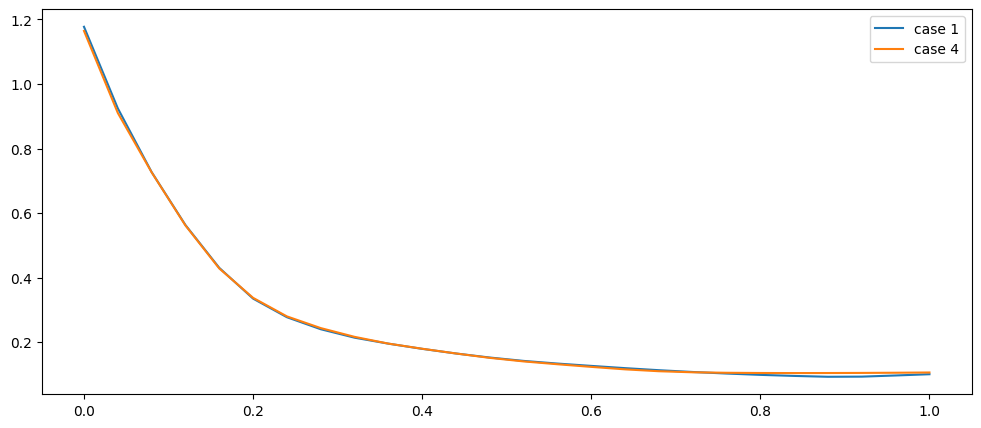

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(r,np.mean(case_1_phi,axis=1), label='case 1')
ax.plot(r,np.mean(case_4_phi,axis=1), label='case 4')

ax.legend()

In [42]:
case_1_Cl = np.mean(case_1_bem[count]['cl'], axis=0)
case_4_Cl = np.mean(case_4_bem[count]['cl'], axis=0)

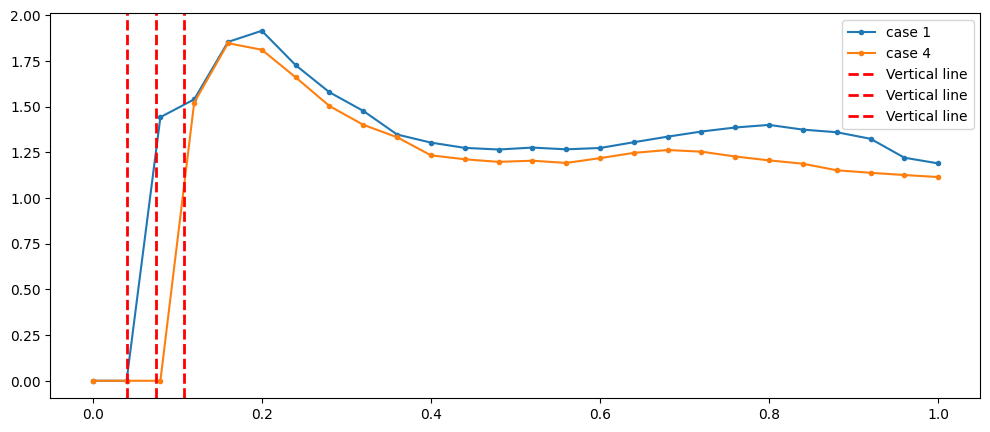

In [61]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(r,np.mean(case_1_Cl,axis=1),marker='.',label='case 1')
ax.plot(r,np.mean(case_4_Cl,axis=1),marker='.',label='case 4')

ax.axvline(x=(2.4 + 1.6)/rotor.R, color='red', linestyle='--', linewidth=2, label="Vertical line")

ax.axvline(x=(2.4 + 5)/rotor.R, color='red', linestyle='--', linewidth=2, label="Vertical line")
ax.axvline(x=(2.4 + 8.3)/rotor.R, color='red', linestyle='--', linewidth=2, label="Vertical line")

ax.legend()

In [49]:
case_1_Cd = np.mean(case_1_bem[count]['cd'], axis=0)
case_4_Cd = np.mean(case_4_bem[count]['cd'], axis=0)

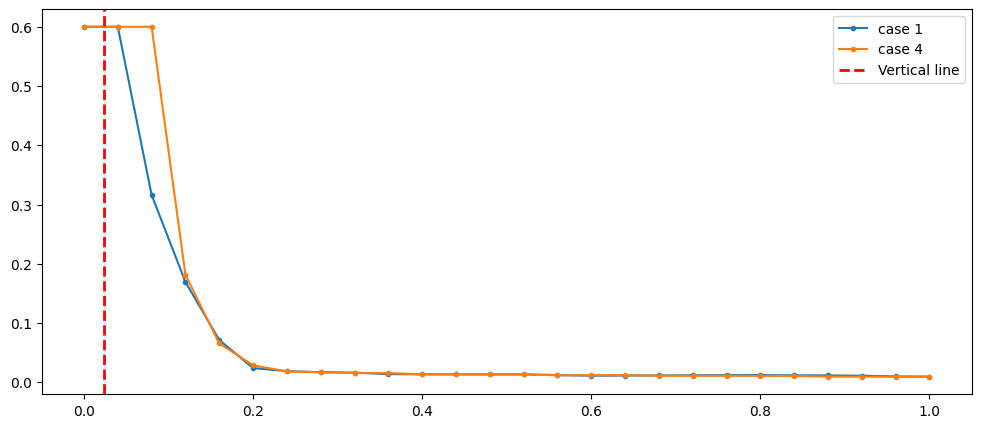

In [50]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(r,np.mean(case_1_Cd,axis=1),marker='.',label='case 1')
ax.plot(r,np.mean(case_4_Cd,axis=1),marker='.',label='case 4')

ax.axvline(x=2.4/rotor.R, color='red', linestyle='--', linewidth=2, label="Vertical line")

ax.legend()

In [ ]:
case_1_twist = np.mean(case_1_bem[count]['cd'], axis=0)
case_4_twist = np.mean(case_4_bem[count]['cd'], axis=0)